In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot  as plt
import seaborn as sns
sns.set()

## The intialization function.

In [2]:
def intialize_weights(layer_dims):
    parameters = {}
    L = len(layer_dims)
    for l in range(L-1) :
        rows = layer_dims[l+1]
        cols = layer_dims[l]
        parameters['W'+str(l+1)] = np.random.uniform(-2.4/cols,2.4/cols,(rows,cols))
        parameters['b'+str(l+1)] = np.zeros([rows,1],dtype=float)
    return  parameters
        

## The Activation functions needed and their deravatives.

In [3]:
def relu(Z):
    return np.maximum(Z,0)
def relu_derivative(A):
    return (A > 0) *1


In [4]:
def sigmoid(Z):
    A = 1/(1+np.exp(-Z))
    return A
def sigmoid_derivative(A):
    return A * (1 - A)

## Forward Propagation.

In [5]:
def forward_propegation(X , Y, parameters):
    L = len(parameters) // 2
    cache = {}
    for l in range(1,L):
        if l==1:
            cache['Z' + str(l)] = np.dot(parameters['W' + str(l)],X) + parameters['b' + str(l)]
            cache['A' + str(l)] = relu(cache['Z' + str(l)])
        else:
            cache['Z' + str(l)] = np.dot(parameters['W' + str(l)],cache['A' + str(l-1)]) + parameters['b' + str(l)]
            cache['A' + str(l)] = relu(cache['Z' + str(l)])         
    cache['Z' + str(L)] = np.dot(parameters['W' + str(L)],cache['A' + str(L-1)]) 
    cache['A' + str(L)] = sigmoid(cache['Z' + str(L)])
    AL = cache['A' + str(L)]
    return AL, cache
        

## Error Calculation.

In [6]:
def Error_calculate(AL , Y , cache, parameters):
    m = Y.shape[1]
    L = len(parameters) // 2
    errors = {}
    Y_k = AL
    # Y is desired output, Y_k is actual output.
    delta_k = sigmoid_derivative(Y_k) * (Y - Y_k)
    errors['delta_'+str(L)] = delta_k
    for l in reversed(range(1,L)):
        Y_j= cache['A'+str(l)]
        delta_j = relu_derivative(Y_j) * np.dot( parameters['W' + str(l+1)].T ,errors['delta_'+ str(l+1)]) 
        errors['delta_'+str(l)] = delta_j
    return errors

        

## Back Propagation.

In [7]:
def Back_propagation(X,parameters, errors, cache, learning_rate = 0.02):
    
    L = len(parameters) // 2
    for l in reversed(range(1,L+1)):
        if l>1:
            Y_j = cache['A' + str(l-1)]
        else:
            Y_j = X
        delta_k = errors['delta_' +str(l)]
        d_w = learning_rate *np.dot( Y_j, delta_k.T)
        d_b = learning_rate *delta_k.T
        parameters['W' + str(l)] = np.add(parameters['W' + str(l)] , d_w.T)
        parameters['b' + str(l)] = np.add(parameters['b' + str(l)] ,np.sum(d_b.T, axis=1, keepdims =True))
    return parameters

## Cost functions 

In [8]:
def root_mean_squared_error(target , actual):
    m = target.shape[0]  
    return np.sqrt((np.sum((target - actual)**2))/m)

In [9]:
def mean_absolute_error(target , actual ,with_mean = True):
    m = target.shape[0]
    if with_mean:
        return (np.abs(target - actual).sum())/m
    else:
        return np.abs(target - actual).sum()

## Building the model all together

In [10]:
def model(X_train , Y_train , layer_dims = [9,100,1], epochs = 1000, learning_rate =0.1):
    np.random.seed(42)
    weights = intialize_weights(layer_dims)
    costs = []
    accs = []
    print('__________________________________________________________')
    for epoch in range(epochs):
        AL , cache = forward_propegation(X_train , Y_train ,weights)
        errors = Error_calculate(AL , Y_train , cache , weights)
        weights = Back_propagation(X_train , weights ,errors, cache, learning_rate  )
        predictions = AL
        predictions[predictions  > 0.6] =1
        predictions[predictions <= 0.6] =0
        cost = root_mean_squared_error(predictions[0], Y_train).round(4)
        acc = 1 - mean_absolute_error(predictions[0] ,Y_train)
        costs.append(cost)
        accs.append(acc)
        if epoch % 50 ==0:
            print('Epoch: ',epoch)
            print('Accuaracy: ',(acc*100).round(2),'%')
            print('Cost: ',cost)
            print('--------------------------------------------------')
    plt.plot(np.arange(epochs) , accs, 'g')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    #plt.savefig('acc.jpg', format='jpg', dpi=1800)
    plt.show()
    return weights #,costs


## Evaluate Function

In [11]:
def evaluate(X , Y, parameters , dataset='Test' ,return_result =True ):
    predictions ,cache = forward_propegation(X , Y, parameters )
    predictions[predictions > 0.6]  =1
    predictions[predictions <= 0.6]  =0
    accuaracy = ((1 - mean_absolute_error(predictions[0] ,Y))*100).round(2)
    cost = root_mean_squared_error(predictions[0], Y).round(4)
    print(dataset,' Accuaracy: ',accuaracy,'%')
    print(dataset,' Cost: ', root_mean_squared_error(predictions[0], Y).round(4))
    if return_result:
        return accuaracy , cost

## Loading the data.

In [12]:
train_set = pd.read_csv('final_train_set.csv',index_col =0)
test_set  = pd.read_csv('final_test_set.csv' ,index_col =0)

In [13]:
x_train = train_set.drop(['Survived'],axis =1)
y_train = train_set.Survived

X_train = x_train.to_numpy().T
Y_train = y_train.to_numpy().reshape(1,-1)

x_test= test_set.drop(['Survived'],axis =1)
y_test = test_set.Survived

X_test = x_test.to_numpy().T
Y_test = y_test.to_numpy().reshape(1,-1)


## Training the model.

__________________________________________________________
Epoch:  0
Accuaracy:  61.46 %
Cost:  0.6208
--------------------------------------------------
Epoch:  50
Accuaracy:  64.51 %
Cost:  0.5957
--------------------------------------------------
Epoch:  100
Accuaracy:  76.46 %
Cost:  0.4852
--------------------------------------------------
Epoch:  150
Accuaracy:  84.46 %
Cost:  0.3943
--------------------------------------------------
Epoch:  200
Accuaracy:  85.62 %
Cost:  0.3792
--------------------------------------------------
Epoch:  250
Accuaracy:  85.71 %
Cost:  0.378
--------------------------------------------------
Epoch:  300
Accuaracy:  85.71 %
Cost:  0.378
--------------------------------------------------
Epoch:  350
Accuaracy:  85.71 %
Cost:  0.378
--------------------------------------------------
Epoch:  400
Accuaracy:  85.8 %
Cost:  0.3768
--------------------------------------------------
Epoch:  450
Accuaracy:  85.89 %
Cost:  0.3756
-----------------------------

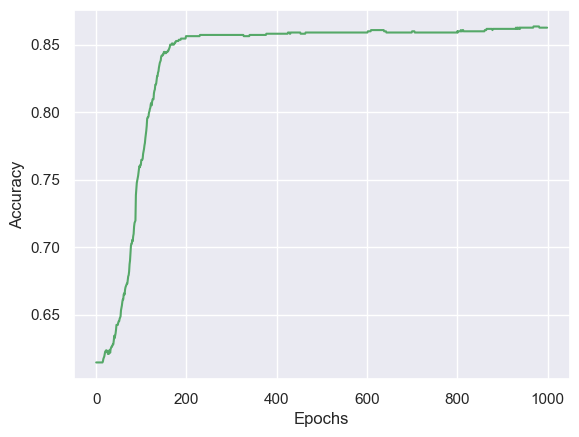

In [17]:
weights= model(X_train , Y_train , layer_dims = [9,50,1], epochs = 1000, learning_rate =0.0005)   

## Evaluating the final model on train and test data.

In [19]:
evaluate(X_test, Y_test, weights , dataset ='Test' , return_result= False)

Test  Accuaracy:  90.82 %
Test  Cost:  0.303
